In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix,precision_score, recall_score,f1_score,roc_curve, roc_auc_score, ConfusionMatrixDisplay, make_scorer
from sklearn.model_selection import train_test_split, cross_val_score, cross_validate, GridSearchCV
import time
from sklearn.compose import ColumnTransformer
import copy
import os

import import_ipynb
import importlib
import functions as fc
importlib.reload(fc)

print(os.getcwd())

import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", category=FutureWarning)


c:\Users\ameli\OneDrive\Studium\TUWien\SS2026\PrivacyInML\Exercise2


In [2]:
cc_train = pd.read_csv("datasets/creditcard_train_resamples.csv")
cc_test = pd.read_csv("datasets/creditcard_test.csv")

cc_train = cc_train.drop("ID", axis = 1)
cc_test = cc_test.drop("ID", axis = 1)

In [3]:
def get_dummies_all(X_train, X_test):
    """
    Converts all categorical variables in a DataFrame into dummy (one-hot encoded) variables.
    """
    categorical_cols = ["MARRIAGE", "SEX", "EDUCATION"]  # Select categorical columns
    X_train_encoded = pd.get_dummies(X_train, columns=categorical_cols, drop_first=True)
    X_test_encoded = pd.get_dummies(X_test, columns=categorical_cols, drop_first=True)
    return X_train_encoded, X_test_encoded

In [4]:
X_train = cc_train.drop('default.payment.next.month', axis = 1)
X_test = cc_test.drop('default.payment.next.month', axis = 1)
y_train = cc_train['default.payment.next.month']
y_test = cc_test['default.payment.next.month']

X_train, X_test = get_dummies_all(X_train, X_test)

In [5]:
numeric_features = [
    "LIMIT_BAL",
    "AGE",
    "BILL_AMT1",
    "BILL_AMT2",
    "BILL_AMT3",
    "BILL_AMT4",
    "BILL_AMT5",
    "BILL_AMT6",
    "PAY_AMT1",
    "PAY_AMT2",
    "PAY_AMT3",
    "PAY_AMT4",
    "PAY_AMT5",
    "PAY_AMT6",
]

ordinal_features = [
    "PAY_0",
    "PAY_2",
    "PAY_3",
    "PAY_4",
    "PAY_5",
    "PAY_6"
]

In [6]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("ord", StandardScaler(), ordinal_features)
    ],
    remainder="passthrough"
)

X_train_sc = pd.DataFrame(
    preprocessor.fit_transform(X_train),
    columns=preprocessor.get_feature_names_out(),
    index=X_train.index
)

X_test_sc = pd.DataFrame(
    preprocessor.transform(X_test),
    columns=preprocessor.get_feature_names_out(),
    index=X_test.index
)

In [7]:
print(X_test_sc.head())

   num__LIMIT_BAL  num__AGE  num__BILL_AMT1  num__BILL_AMT2  num__BILL_AMT3  \
0       -0.987556 -1.130032       -0.560318       -0.537604       -0.500551   
1       -0.032636 -1.023458        1.167285        1.075205        1.005809   
2       -0.669249 -0.384010        0.267302        0.285872        0.315655   
3       -0.191789  1.427759       -0.400706       -0.413506       -0.434752   
4       -0.828403  0.042289        0.592984       -0.013349       -0.059405   

   num__BILL_AMT4  num__BILL_AMT5  num__BILL_AMT6  num__PAY_AMT1  \
0       -0.468747       -0.431035       -0.403684      -0.227715   
1        0.910961        0.613932        0.644591      -0.024610   
2        0.417558        0.489401        0.526191      -0.164389   
3       -0.401808       -0.471511       -0.536053      -0.220233   
4       -0.360325       -0.323657       -0.326267      -0.193706   

   num__PAY_AMT2  ...  ord__PAY_5  ord__PAY_6  remainder__MARRIAGE_2  \
0      -0.148541  ...    0.083167    0.11085

### Fit the model

In [8]:
model = LogisticRegression(
    penalty="l2",
    C=1,
    max_iter=1000,
    random_state=42
)
model.fit(X_train_sc, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'l2'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To ch

### Prediction and utility

In [9]:
print("Training set: ")
fc.predict_binary(model, X_train_sc, y_train, conf_matrix=False)

Training set: 
---------------------------------------
Accuracy: 0.6725
Precision: 0.6830
Recall: 0.6438
F1 Score: 0.6628
---------------------------------------


---------------------------------------
Accuracy: 0.6900
Precision: 0.3788
Recall: 0.6512
F1 Score: 0.4790
---------------------------------------
          Predicted 0  Predicted 1
Actual 0         3285         1402
Actual 1          458          855


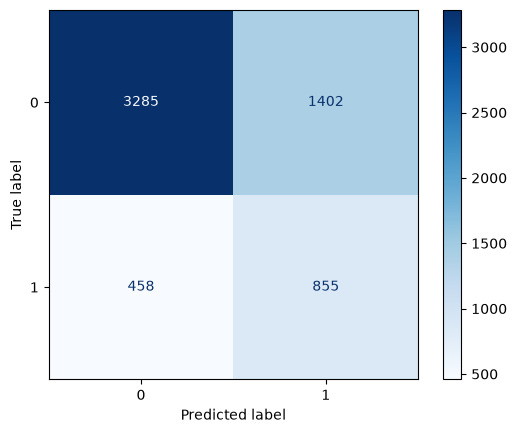

Saved results to results/model_results_cc.xlsx


In [10]:
fc.predict_binary_save_results(
    model,
    X_test_sc,
    y_test,
    conf_matrix = True,
    perturbation_type="Original_oversampled",
    epsilon=0,
    output_file="results/model_results_cc.xlsx"
)

In [11]:
fc.cross_validate_model(model, X_train_sc, y_train, cv=10, bivariate = True)

Accuracy: 0.6719
Precision: 0.6822
Recall: 0.6436
F1 Score: 0.6623
Time: 2.518864631652832


{'fit_time': array([0.23984194, 0.22211623, 0.2272284 , 0.21363831, 0.21931434,
        0.23400259, 0.23299527, 0.26648903, 0.22169542, 0.20555496]),
 'score_time': array([0.02418733, 0.02315187, 0.02453995, 0.02039242, 0.02291036,
        0.02094364, 0.01652503, 0.02595043, 0.01688647, 0.02459526]),
 'test_accuracy': array([0.6753212 , 0.66729122, 0.67103854, 0.66836188, 0.67550201,
        0.68487282, 0.66746988, 0.67657296, 0.67202142, 0.66024096]),
 'test_precision': array([0.68144044, 0.67745599, 0.68586387, 0.67599328, 0.69007545,
        0.6978211 , 0.67705382, 0.68728717, 0.67811634, 0.67124071]),
 'test_recall': array([0.65845824, 0.63865096, 0.63115632, 0.64668094, 0.63685056,
        0.65184788, 0.64006427, 0.64828694, 0.65524625, 0.62847966]),
 'test_f1': array([0.66975225, 0.6574814 , 0.65737385, 0.66101231, 0.66239554,
        0.67405151, 0.65803965, 0.66721763, 0.66648516, 0.64915676])}

In [12]:
fc.hyperparameterTuning_save_Results(X_train_sc, y_train, cv=10, bivariate = True, perturbation_type="Original_hpt_oversampled",
        epsilon=0, output_file="results/model_results_cc.xlsx")

Best parameters: {'C': 0.01}
Accuracy : 0.6737
Precision: 0.6855
Recall   : 0.6421
F1 Score : 0.6630
Time     : 11.99 s


(LogisticRegression(C=0.01), {'C': 0.01})

----------------------------------------------------------------------------------------------
-------------------------------------- INPUT PERTUBATION -------------------------------------
----------------------------------------------------------------------------------------------

### Perturb dataset

In [13]:
print(X_train.columns)

Index(['LIMIT_BAL', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5',
       'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4',
       'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3',
       'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'MARRIAGE_2', 'MARRIAGE_3', 'SEX_2',
       'EDUCATION_2', 'EDUCATION_3', 'EDUCATION_4', 'EDUCATION_5',
       'EDUCATION_6'],
      dtype='str')


In [14]:
ranges = [[1000,1000000], [18,100], [-2,8], [-2,8], [-2,8], [-2,8], [-2,8],
       [-2,8], [-10000,500000], [-10000,500000], [-10000,500000], [-10000,500000],
       [-10000,500000],[-10000,500000], [0,250000], [0,250000], [0,250000],
       [0,250000], [0,250000], [0,250000], [0,1], [0,1], [0,1],
       [0,1], [0,1], [0,1], [0,1], [0,1]]
print(ranges)

sensitivity = []
for range in ranges:
    sensitivity.append(range[1]-range[0])
print(sensitivity)


[[1000, 1000000], [18, 100], [-2, 8], [-2, 8], [-2, 8], [-2, 8], [-2, 8], [-2, 8], [-10000, 500000], [-10000, 500000], [-10000, 500000], [-10000, 500000], [-10000, 500000], [-10000, 500000], [0, 250000], [0, 250000], [0, 250000], [0, 250000], [0, 250000], [0, 250000], [0, 1], [0, 1], [0, 1], [0, 1], [0, 1], [0, 1], [0, 1], [0, 1]]
[999000, 82, 10, 10, 10, 10, 10, 10, 510000, 510000, 510000, 510000, 510000, 510000, 250000, 250000, 250000, 250000, 250000, 250000, 1, 1, 1, 1, 1, 1, 1, 1]


In [15]:
X_train_clipped = X_train.copy()
for i, col in enumerate(X_train.columns):
    lower, upper = ranges[i]
    X_train_clipped[col] = X_train_clipped[col].clip(lower=lower, upper=upper)

In [16]:
epsilon_values = [0.1, 1, 5, 10, 30, 50, 100]
perturbed_datasets = {}

np.random.seed(42)
for e in epsilon_values:
    X_train_perturbed = X_train_clipped.copy()
    d = X_train_perturbed.shape[1]

    for i, var in enumerate(X_train_clipped.columns):
        eps_j = e # The paper uses eps_j = e/d, but this leades to huge errors
        scale = sensitivity[i] / eps_j   
        noise = np.random.laplace(loc=0,scale=scale,size=len(X_train_clipped))

        lower, upper = ranges[i]
        X_train_perturbed[var] = (
            X_train[var] + noise
        ).clip(lower=lower, upper=upper)

    perturbed_datasets[e] = X_train_perturbed

### Fit the model with the new datasets

In [17]:
for e in epsilon_values:
    input_model = copy.deepcopy(model)

    X_train_input = perturbed_datasets[e]
    scaler = StandardScaler()
    X_train_input_sc = scaler.fit_transform(X_train_input)
    X_test_input_sc = scaler.transform(X_test)

    input_model.fit(X_train_input_sc, y_train)

    # Predict on training set
    print("Training set: ")
    fc.predict_binary(input_model, X_train_input_sc, y_train, conf_matrix=False)

    #Predict on testset
    fc.predict_binary_save_results(
        input_model,
        X_test_input_sc,
        y_test,
        conf_matrix = False,
        perturbation_type="Input",
        epsilon=e,
        output_file="results/model_results_cc.xlsx"
    )

    fc.hyperparameterTuning_save_Results(X_train_input_sc, y_train, cv=10, bivariate = True, perturbation_type="Input_hpt_oversampled",
        epsilon=e, output_file="results/model_results_cc.xlsx")


Training set: 
---------------------------------------
Accuracy: 0.5145
Precision: 0.5145
Recall: 0.5142
F1 Score: 0.5143
---------------------------------------
---------------------------------------
Accuracy: 0.7815
Precision: 0.6667
Recall: 0.0030
F1 Score: 0.0061
---------------------------------------
Saved results to results/model_results_cc.xlsx
Best parameters: {'C': 0.01}
Accuracy : 0.5081
Precision: 0.5081
Recall   : 0.5085
F1 Score : 0.5083
Time     : 0.76 s
Training set: 
---------------------------------------
Accuracy: 0.5379
Precision: 0.5386
Recall: 0.5290
F1 Score: 0.5338
---------------------------------------
---------------------------------------
Accuracy: 0.7642
Precision: 0.4431
Recall: 0.3024
F1 Score: 0.3594
---------------------------------------
Saved results to results/model_results_cc.xlsx
Best parameters: {'C': 0.01}
Accuracy : 0.5356
Precision: 0.5362
Recall   : 0.5273
F1 Score : 0.5317
Time     : 0.75 s
Training set: 
-----------------------------------

----------------------------------------------------------------------------------------------
------------------------------------- OUTPUT PERTUBATION -------------------------------------
----------------------------------------------------------------------------------------------

In [18]:
n = X_train.shape[0]
#C_x = np.max(np.linalg.norm(X_train, axis=1))
lambda_reg = 1 / model.C
sensitivity = (2) / (lambda_reg * n)

epsilon_values = [0.1, 1, 5, 10, 30, 50, 100]
perturbed_coefficients = {}

np.random.seed(42)
for e in epsilon_values:
    coef_noise = np.random.laplace(loc=0,scale=sensitivity / e,size=model.coef_.shape)
    intercept_noise = np.random.laplace(loc=0,scale=sensitivity / 3,size=model.intercept_.shape)
    perturbed_coefficients[e] = {
        "coef": model.coef_ + coef_noise,
        "intercept": model.intercept_ + intercept_noise
    }

In [19]:
for e in epsilon_values:
    output_model = copy.deepcopy(model)

    output_model.coef_ = perturbed_coefficients[e]["coef"]
    output_model.intercept_ = perturbed_coefficients[e]["intercept"]

    # Predict on training set
    print("Training set: ")
    fc.predict_binary(output_model, X_train_sc, y_train, conf_matrix=False)

    #Predict on testset
    fc.predict_binary_save_results(
        output_model,
        X_test_sc,
        y_test,
        conf_matrix = False,
        perturbation_type="Output_oversampled",
        epsilon=e,
        output_file="results/model_results_cc.xlsx"
    )

Training set: 
---------------------------------------
Accuracy: 0.6725
Precision: 0.6831
Recall: 0.6437
F1 Score: 0.6628
---------------------------------------
---------------------------------------
Accuracy: 0.6895
Precision: 0.3782
Recall: 0.6504
F1 Score: 0.4783
---------------------------------------
Saved results to results/model_results_cc.xlsx
Training set: 
---------------------------------------
Accuracy: 0.6725
Precision: 0.6829
Recall: 0.6438
F1 Score: 0.6628
---------------------------------------
---------------------------------------
Accuracy: 0.6897
Precision: 0.3784
Recall: 0.6504
F1 Score: 0.4784
---------------------------------------
Saved results to results/model_results_cc.xlsx
Training set: 
---------------------------------------
Accuracy: 0.6725
Precision: 0.6830
Recall: 0.6438
F1 Score: 0.6628
---------------------------------------
---------------------------------------
Accuracy: 0.6898
Precision: 0.3787
Recall: 0.6512
F1 Score: 0.4789
-------------------

----------------------------------------------------------------------------------------------
------------------------------------ INTERNAL PERTUBATION ------------------------------------
----------------------------------------------------------------------------------------------

In [20]:
# data_norm = np.max(np.linalg.norm(np.asarray(X_train_sc), axis=1))
# print("data_norm (max L2 norm of a scaled training row):", data_norm)


In [21]:
# epsilon_values = [0.1, 1, 5, 10, 30, 50, 100]

# internal_models = fc.internal_perturbation_save_results(
#     X_train_sc,
#     y_train,
#     X_test_sc,
#     y_test,
#     epsilon_values=epsilon_values,
#     data_norm=data_norm,
#     C=model.C,
#     bivariate=True,
#     output_file="results/model_results_cc.xlsx",
#     perturbation_type="Internal_oversampled"
# )

